
# **Interview-Technical Task**

In [24]:
# Importing essential libraries for use
import pandas as pd
import numpy as np
import warnings # To hide the warning text messages
warnings.filterwarnings('ignore')

well1=pd.read_csv('well_01_DHP_data..csv')
well1.head()

,timestamp,dhp
0,2015-03-14T08:16:11.300Z,4448.07000
1,2015-03-14T08:16:11.378Z,4448.06543
2,2015-03-14T09:04:53.200Z,4447.92000
3,2015-03-14T09:04:53.269Z,4447.91650
4,2015-03-14T10:04:45.100Z,4447.78000


In [27]:
well1.info()
well1.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7866706 entries, 0 to 7866705
Data columns (total 2 columns):
 #   Column     Dtype  
---  ------     -----  
 0   timestamp  object 
 1   dhp        float64
dtypes: float64(1), object(1)
memory usage: 120.0+ MB


(7866706, 2)

In [ ]:
# function for make correct format for timestamp column
def clean_timestamp(ts):
    parsed = pd.to_datetime(ts, format='mixed', utc=True, errors='coerce')

    if parsed.isna().mean() > 0.3:
        date_part = ts.str[:11]
        time_part = ts.str[11:].str.replace('-', ':')
        fixed = date_part + time_part
        parsed = pd.to_datetime(fixed, format='mixed', utc=True, errors='coerce')

    return parsed

In [ ]:
# loading the csv files after converting timestamp object dtype into datetime
# setting timestamp as index so we can slice by time ( like df.loc[start:end]) and resample
def load_well(path, freq='5min', nrows=None):
    df = pd.read_csv(path, nrows=nrows)
    df.columns = [c.lower() for c in df.columns]

    ts = df['timestamp'].astype(str)
    df['timestamp'] = clean_timestamp(ts)
    df = df.dropna(subset=['timestamp'])

    df = df.set_index('timestamp').sort_index()
    df_resampled = df.resample(freq).mean(numeric_only=True).dropna()

    return df, df_resampled

In [14]:
# SECTION 1-SOLUTION

# # here we detect pressure build-ups (PBUs) in the pressure data
# we first smooth the raw pressure to remove noise, then check where it's
# steadily increasing. we group consecutive rising points into one event,
# and keep only the events that last at least 2 hours and rise at least 600 psi
# as required by the task, we also add 1.5 hours of padding before/after each
# PBU, and return everything as a table

def detect_pbu(df, min_increase=600, min_hours=2, smooth=5, tol=0.02):
    df = df.copy()
    df['smooth'] = df['dhp'].rolling(smooth, center=True, min_periods=1).mean()

    diff = df['smooth'].diff()
    rising = diff > tol
    group = (rising != rising.shift()).cumsum()

    results = []
    for g, seg in df[rising].groupby(group[rising]):
        i0 = max(df.index.get_loc(seg.index[0]) - 1, 0)
        i1 = min(df.index.get_loc(seg.index[-1]) + 1, len(df) - 1)

        t_start, t_end = df.index[i0], df.index[i1]
        p_start, p_end = df['smooth'].iloc[i0], df['smooth'].iloc[i1]

        duration = (t_end - t_start).total_seconds() / 3600
        change = p_end - p_start

        if duration >= min_hours and change >= min_increase:
            results.append({
                'exact_start': t_start,
                'interval_start': t_start - pd.Timedelta(hours=1.5),
                'exact_end': t_end,
                'interval_end': t_end + pd.Timedelta(hours=1.5),
                'duration_hours': round(duration, 2),
                'pressure_change': round(change, 2)
            })
    return pd.DataFrame(results)



In [15]:
# loading the files, detecting the pbu's and transfering into csv files
well1_raw, well1 = load_well('well_01_DHP_data..csv')
pbu1 = detect_pbu(well1)
print(pbu1)

well2_raw, well2 = load_well('well_02_DHP_data..csv')
pbu2 = detect_pbu(well2)
print(pbu2)

well3_raw, well3 = load_well('well_03_DHP_data..csv')
pbu3 = detect_pbu(well3)
print(pbu3)

pbu1.to_csv('well1_pbu_results.csv', index=False)
pbu2.to_csv('well2_pbu_results.csv', index=False)
pbu3.to_csv('well3_pbu_results.csv', index=False)

                 exact_start            interval_start  \
0  2015-03-16 00:25:00+00:00 2015-03-15 22:55:00+00:00   
1  2015-03-17 14:00:00+00:00 2015-03-17 12:30:00+00:00   
2  2015-04-09 14:10:00+00:00 2015-04-09 12:40:00+00:00   
3  2015-07-04 03:40:00+00:00 2015-07-04 02:10:00+00:00   
4  2015-07-09 18:00:00+00:00 2015-07-09 16:30:00+00:00   
5  2015-10-02 10:20:00+00:00 2015-10-02 08:50:00+00:00   
6  2015-10-13 21:35:00+00:00 2015-10-13 20:05:00+00:00   
7  2015-12-17 01:30:00+00:00 2015-12-17 00:00:00+00:00   
8  2016-02-28 05:05:00+00:00 2016-02-28 03:35:00+00:00   
9  2016-04-12 20:45:00+00:00 2016-04-12 19:15:00+00:00   
10 2016-06-03 11:45:00+00:00 2016-06-03 10:15:00+00:00   
11 2016-09-25 12:35:00+00:00 2016-09-25 11:05:00+00:00   
12 2016-09-27 02:20:00+00:00 2016-09-27 00:50:00+00:00   
13 2016-10-01 08:25:00+00:00 2016-10-01 06:55:00+00:00   
14 2016-12-26 19:10:00+00:00 2016-12-26 17:40:00+00:00   
15 2017-03-24 16:15:00+00:00 2017-03-24 14:45:00+00:00   
16 2017-05-31 

In [ ]:
# Section 2

# We use curve_fit to estimate reservoir pressure for each PBU. The idea is that
# during a pressure build-up, the pressure rises fast at first and then levels off
# toward a flat value - that flat value is the reservoir pressure we want
# Instead of guessing where it flattens, we fit the raw data to an exponential
# curve (fast rise, then flat), and let the fit tell us exactly what that flat
# value (P_res) is. We do this separately for every PBU we detected in well3

from scipy.optimize import curve_fit


def exp_model(dt, P_res, A, tau):
    return P_res - A * np.exp(-dt / tau)


def get_reservoir_pressure(raw_df, t_start, t_end):
    seg = raw_df.loc[t_start:t_end]
    dt = (seg.index - seg.index[0]).total_seconds() / 3600
    p = seg['dhp'].values

    p0 = [p.max(), p.max() - p.min(), 1.0]
    try:
        params, _ = curve_fit(exp_model, dt, p, p0=p0, maxfev=10000)
        return params[0]
    except RuntimeError:
        return np.nan

In [17]:
# reusing well3_raw and pbu3 from section 1 (full data, already loaded there)
pbu3['reservoir_pressure'] = pbu3.apply(
    lambda row: get_reservoir_pressure(well3_raw, row['exact_start'], row['exact_end']),
    axis=1
)
print(pbu3)


                 exact_start            interval_start  \
0  2015-02-18 10:10:00+00:00 2015-02-18 08:40:00+00:00   
1  2015-02-26 21:50:00+00:00 2015-02-26 20:20:00+00:00   
2  2016-01-09 01:45:00+00:00 2016-01-09 00:15:00+00:00   
3  2016-04-21 19:45:00+00:00 2016-04-21 18:15:00+00:00   
4  2016-05-19 03:15:00+00:00 2016-05-19 01:45:00+00:00   
5  2016-05-25 18:20:00+00:00 2016-05-25 16:50:00+00:00   
6  2016-05-28 00:35:00+00:00 2016-05-27 23:05:00+00:00   
7  2016-06-02 09:40:00+00:00 2016-06-02 08:10:00+00:00   
8  2016-08-02 21:00:00+00:00 2016-08-02 19:30:00+00:00   
9  2016-10-01 08:15:00+00:00 2016-10-01 06:45:00+00:00   
10 2016-11-22 17:35:00+00:00 2016-11-22 16:05:00+00:00   
11 2017-04-13 09:55:00+00:00 2017-04-13 08:25:00+00:00   
12 2017-08-21 04:00:00+00:00 2017-08-21 02:30:00+00:00   
13 2017-11-23 23:25:00+00:00 2017-11-23 21:55:00+00:00   
14 2018-01-23 12:10:00+00:00 2018-01-23 10:40:00+00:00   
15 2018-05-02 00:00:00+00:00 2018-05-01 22:30:00+00:00   
16 2018-05-15 

In [ ]:
# looking at 0th or 4th rows, the res pressure seems a lot which curve_fit failed, so it is better to change them as nan
pbu3['reservoir_pressure'] = pbu3['reservoir_pressure'].where(
    pbu3['reservoir_pressure'].between(1000, 10000), np.nan
)
print(pbu3)

In [29]:
# again transfering the results into a new csv file
pbu3.to_csv(r'C:\Users\ASUS\Desktop\section2_well3_pbu_results.csv', index=False)

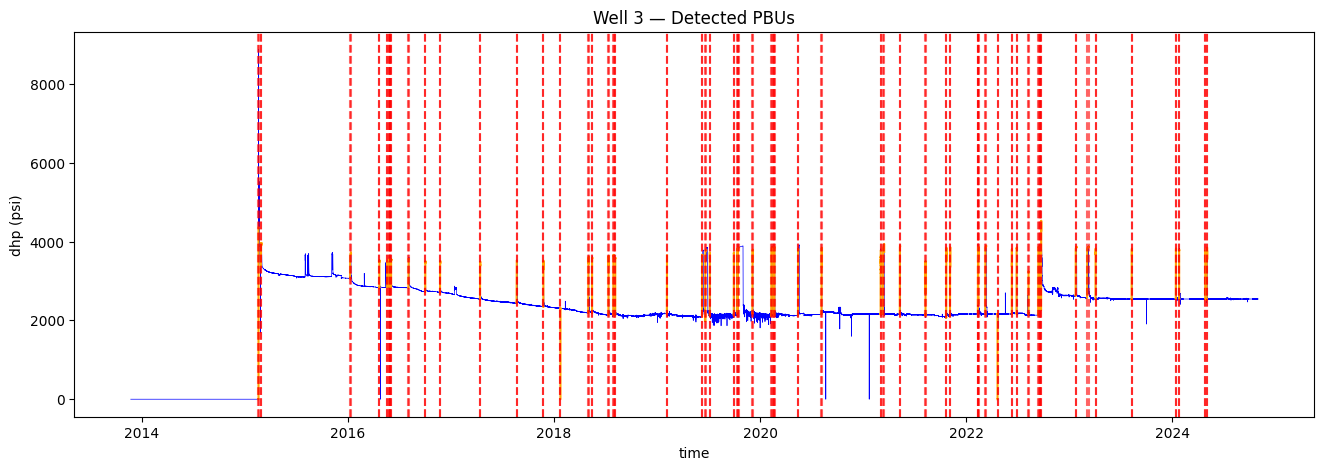

In [30]:
# visualization part
import matplotlib.pyplot as plt

def plot_pbu(df, pbu_table, well_name):
    plt.figure(figsize=(16, 5))
    plt.plot(df.index, df['dhp'], color='blue', linewidth=0.5, label='pressure')

    for _, row in pbu_table.iterrows():
        seg = df.loc[row['interval_start']:row['interval_end']]
        plt.plot(seg.index, seg['dhp'], color='orange', linewidth=1.5)
        plt.axvline(row['exact_start'], color='red', linestyle='--', alpha=0.6)
        plt.axvline(row['exact_end'], color='red', linestyle='--', alpha=0.6)

    plt.title(f'{well_name} — Detected PBUs')
    plt.xlabel('time')
    plt.ylabel('dhp (psi)')
    plt.show()

plot_pbu(well3, pbu3, 'Well 3')